In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../dataset/train.csv")
X_train = df1.drop(columns = ['Churn'])
y_train = df1['Churn'].values
df2 = pd.read_csv("../dataset/test.csv")
X_test = df2.drop(columns = ['Churn'])
y_test = df2['Churn'].values

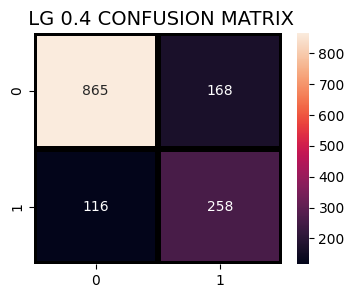

In [3]:
#normal log regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
#test
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
#lower threshold into 0.4 instead of default = 0.5
threshold = 0.4
y_pred_log_adj = (y_prob_log >= threshold).astype(int)

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_log_adj), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title(" LG 0.4 CONFUSION MATRIX",fontsize=14)
plt.show()

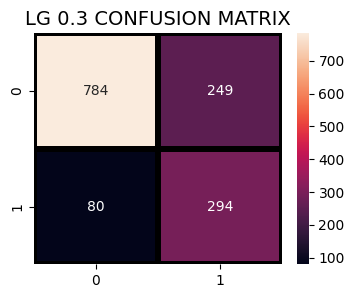

In [4]:
#threshold = 0.3
threshold = 0.3
y_pred_log_adj = (y_prob_log >= threshold).astype(int)

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_log_adj), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("LG 0.3 CONFUSION MATRIX",fontsize=14)
plt.show()

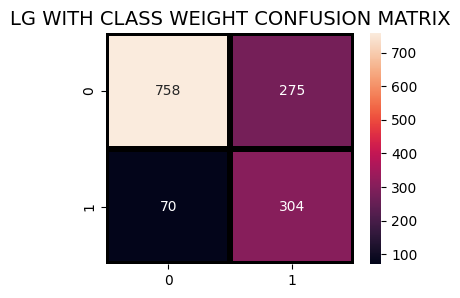

In [5]:
#adding class weight = balanced
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
#using best threshold (default)
threshold = 0.5
y_pred_log_adj = (y_prob_log >= threshold).astype(int)

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_log_adj), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("LG WITH CLASS WEIGHT CONFUSION MATRIX",fontsize=14)
plt.show()

Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


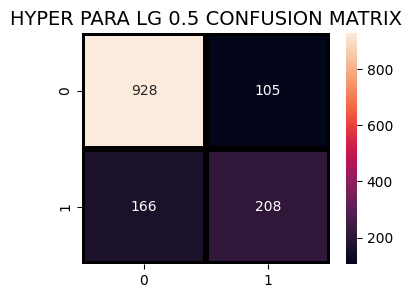

In [6]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1'
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_model = grid.best_estimator_
y_prob = best_model.predict_proba(X_test)[:,1]
y_pred_hyper = (y_prob >= 0.5).astype(int)

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_hyper), annot=True,fmt = "d",linecolor="k",linewidths=3)
plt.title("HYPER PARA LG 0.5 CONFUSION MATRIX",fontsize=14)
plt.show()

In [7]:
#summary
data = {
    "Model": [
        "Logistic (original - threshold=0.5)",
        "Logistic (threshold=0.4)",
        "Logistic (threshold=0.3)",
        "Logistic (balanced class weight)",
        "Logistic (hyperparameter)"
    ],
    "TN": [919, 865, 784, 758, 928],
    "FN": [114, 168, 249, 275, 105],
    "FP": [161, 116, 80, 70, 166],
    "TP": [213, 258, 294, 304, 208]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,TN,FN,FP,TP
0,Logistic (original - threshold=0.5),919,114,161,213
1,Logistic (threshold=0.4),865,168,116,258
2,Logistic (threshold=0.3),784,249,80,294
3,Logistic (balanced class weight),758,275,70,304
4,Logistic (hyperparameter),928,105,166,208


In [9]:
#tổng kết
data = {
    "Model": [
        "Logistic (original - threshold=0.5)",
        "Logistic (threshold=0.4)",
        "Logistic (threshold=0.3)",
        "Logistic (balanced class weight)",
        "Logistic (hyperparameter)"
    ],
    "Accuracy": [0.81, 0.80, 0.77, 0.76, 0.81],
    "Precision": [0.85, 0.88, 0.91, 0.92, 0.85],
    "Recall": [0.89, 0.84, 0/76, 0.73, 0.90],
    "F1-score": [0.87, 0.86, 0.83, 0.82, 0.87]
}

df_results = pd.DataFrame(data)

styled_results = (
    df_results.style
    .background_gradient(cmap="Blues")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid black"),
            ("text-align", "center"),
            ("padding", "6px")
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse")
        ]}
    ])
)

styled_results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic (original - threshold=0.5),0.810000,0.850000,0.890000,0.870000
1,Logistic (threshold=0.4),0.800000,0.880000,0.840000,0.860000
2,Logistic (threshold=0.3),0.770000,0.910000,0.000000,0.830000
3,Logistic (balanced class weight),0.760000,0.920000,0.730000,0.820000
4,Logistic (hyperparameter),0.810000,0.850000,0.900000,0.870000
